In [1]:
import pandas as pd
import numpy as np
import ast
import re
from tqdm import tqdm

In [2]:
models = ['extended_double', 'extended_doublemlploss', 'extendedBase', 'original']

In [3]:
# def interpolate_array(arr):
#     arr_float = arr.astype(float)
#     valid = ~np.isnan(arr_float)
#     indices = np.arange(len(arr_float))
#     arr_float[np.isnan(arr_float)] = np.interp(indices[np.isnan(arr_float)], indices[valid], arr_float[valid])
#     return arr_float
#
#
# dataframe_dict = {}
#
# for m in tqdm(models):
#     curve_df = pd.read_csv(f'./{m}_predictions_for_curves_full451.csv')
#     curve_df['score'] = curve_df['score'].apply(lambda x: np.array(ast.literal_eval(re.sub(r'np\.float64\(([^)]+)\)', r'\1', x).replace('nan', 'None')))).apply(interpolate_array)
#     curve_df['prob'] = curve_df['prob'].apply(lambda x: np.array(ast.literal_eval(re.sub(r'np\.float64\(([^)]+)\)', r'\1', x).replace('nan', 'None')))).apply(interpolate_array)
#     dataframe_dict[m] = curve_df

In [4]:
# pd.to_pickle(dataframe_dict, './curves_all_models_user451.pkl')

In [5]:
dataframe_dict = pd.read_pickle('./curves_all_models_user451.pkl')

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.dates as mdates
import datetime
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, LogFormatterSciNotation
import matplotlib.gridspec as gridspec


def plot_dual_interaction_impact(time_vals, probabilities, scores, time_sim, similarities,
                                 cmap='plasma', min_similarity=0.01, target_bins=80, save_path=None):
    """
    Plots two stacked time series with aligned widths, plus a fixed-range histogram
    of interaction similarities.

    Key behavior
    ------------
    - Histogram x-axis is always logarithmic and fixed to [1e-6, 1].
    - Histogram y-axis is logarithmic (counts per bin).
    - Color mapping is logarithmic and uses the same fixed range [1e-6, 1].
    - Similarity values below 1e-6 are clipped into the first histogram bin and
      mapped to the lowest colormap color.
    - Similarity values above 1 are clipped to 1 for coloring/histogram display.

    Notes
    -----
    The function interface is unchanged, so the default `min_similarity=0.01`
    still filters out values below 0.01. To visualize the full low-similarity
    range, call with:
        min_similarity=None
    or:
        min_similarity=0.0
    """

    # ==========================================
    # FIXED DISPLAY RANGES
    # ==========================================
    SIM_DISPLAY_MIN = 1e-4
    SIM_DISPLAY_MAX = 1.0

    # ==========================================
    # INPUT NORMALIZATION & VALIDATION
    # ==========================================
    time_vals = np.asarray(time_vals, dtype=float)
    probabilities = np.asarray(probabilities, dtype=float)
    scores = np.asarray(scores, dtype=float)
    time_sim = np.asarray(time_sim, dtype=float)
    similarities = np.asarray(similarities, dtype=float)

    for name, arr in (
        ("time_vals", time_vals),
        ("probabilities", probabilities),
        ("scores", scores),
        ("time_sim", time_sim),
        ("similarities", similarities),
    ):
        if arr.ndim != 1:
            raise ValueError(f"{name} must be a 1D array-like input.")

    if len(time_vals) == 0:
        raise ValueError("time_vals must not be empty.")

    if len(probabilities) != len(time_vals):
        raise ValueError("probabilities must have the same length as time_vals.")

    if len(scores) != len(time_vals):
        raise ValueError("scores must have the same length as time_vals.")

    if len(time_sim) != len(similarities):
        raise ValueError("time_sim and similarities must have the same length.")

    if not np.all(np.isfinite(time_vals)):
        raise ValueError("time_vals contains NaN or infinite values.")

    if not np.all(np.isfinite(probabilities)):
        raise ValueError("probabilities contains NaN or infinite values.")

    if not np.all(np.isfinite(scores)):
        raise ValueError("scores contains NaN or infinite values.")

    if len(time_sim) > 0:
        valid_interactions = np.isfinite(time_sim) & np.isfinite(similarities)
        dropped = np.count_nonzero(~valid_interactions)
        if dropped > 0:
            print(f"Warning: Dropped {dropped} interaction(s) with NaN/inf values.")
        time_sim = time_sim[valid_interactions]
        similarities = similarities[valid_interactions]

    if target_bins is None or int(target_bins) < 2:
        raise ValueError("target_bins must be an integer >= 2.")
    target_bins = int(target_bins)

    # ==========================================
    # SORT PRIMARY SERIES FOR PLOTTING / INTERPOLATION
    # ==========================================
    sort_main = np.argsort(time_vals)
    time_vals = time_vals[sort_main]
    probabilities = probabilities[sort_main]
    scores = scores[sort_main]

    def _prepare_interp_xy(x, y):
        unique_x, inverse, counts = np.unique(x, return_inverse=True, return_counts=True)
        if len(unique_x) == len(x):
            return x, y
        y_sum = np.bincount(inverse, weights=y)
        unique_y = y_sum / counts
        return unique_x, unique_y

    interp_time_prob, interp_prob = _prepare_interp_xy(time_vals, probabilities)
    interp_time_score, interp_score = _prepare_interp_xy(time_vals, scores)

    # ==========================================
    # FILTER & SORT INTERACTIONS
    # ==========================================
    if min_similarity is not None:
        mask = similarities >= min_similarity
        removed = np.count_nonzero(~mask)
        time_sim = time_sim[mask]
        similarities = similarities[mask]

        if len(similarities) == 0:
            print(f"Warning: No interactions >= {min_similarity}.")
        elif removed > 0 and min_similarity > 0:
            print(
                f"Note: {removed} interaction(s) below min_similarity={min_similarity} were excluded. "
                f"Set min_similarity=None or 0.0 to show the full low-similarity range."
            )

    if len(similarities) > 0:
        sort_interactions = np.argsort(similarities)
        time_sim = time_sim[sort_interactions]
        similarities = similarities[sort_interactions]

    # ==========================================
    # DATETIME CONVERSION
    # ==========================================
    dates_vals = [datetime.datetime.fromtimestamp(ts) for ts in time_vals]
    dates_sim = [datetime.datetime.fromtimestamp(ts) for ts in time_sim] if len(time_sim) > 0 else []

    # ==========================================
    # FIGURE SETUP
    # ==========================================
    fig = plt.figure(figsize=(14, 12), facecolor='white')
    gs = gridspec.GridSpec(
        3, 2,
        width_ratios=[40, 1],
        height_ratios=[3, 3, 1.8],
        wspace=0.02,
        hspace=0.28
    )

    ax_prob = fig.add_subplot(gs[0, 0])
    ax_cbar = fig.add_subplot(gs[0, 1])
    ax_score = fig.add_subplot(gs[1, 0], sharex=ax_prob)
    ax_hist = fig.add_subplot(gs[2, 0])

    # ==========================================
    # FIXED LOG COLOR NORMALIZATION
    # ==========================================
    cmap_obj = plt.get_cmap(cmap)
    color_norm = LogNorm(vmin=SIM_DISPLAY_MIN, vmax=SIM_DISPLAY_MAX, clip=True)

    if len(similarities) > 0:
        sim_for_color = np.clip(similarities, SIM_DISPLAY_MIN, SIM_DISPLAY_MAX)
        event_colors = cmap_obj(color_norm(sim_for_color))
    else:
        event_colors = np.empty((0, 4))

    # ==========================================
    # AXIS LIMITS FOR TIME SERIES
    # ==========================================
    if len(dates_vals) == 1:
        delta = datetime.timedelta(seconds=1)
        xlim_left = dates_vals[0] - delta
        xlim_right = dates_vals[0] + delta
    else:
        xlim_left = dates_vals[0]
        xlim_right = dates_vals[-1]

    # ==========================================
    # TIME SERIES RENDERING
    # ==========================================
    def draw_curve(ax, y_vals, ylabel, interp_x, interp_y, title=None, show_x_labels=False):
        y_vals = np.asarray(y_vals, dtype=float)

        if len(y_vals) == 0:
            raise ValueError(f"{ylabel} series must not be empty.")

        if len(y_vals) != len(time_vals):
            raise ValueError(f"{ylabel} series must have the same length as time_vals.")

        y_min = np.min(y_vals)
        y_max = np.max(y_vals)
        y_range = y_max - y_min
        if y_range == 0:
            y_range = 1e-5

        ymin = y_min - (y_range * 0.10)
        ymax = y_max + (y_range * 0.15)

        ax.grid(axis='y', color='#eeeeee', linestyle='-', linewidth=1, zorder=0)

        ax.plot(
            dates_vals, y_vals,
            color='#151515',
            linewidth=2.5,
            alpha=1.0,
            path_effects=[pe.Stroke(linewidth=5.5, foreground='white'), pe.Normal()],
            zorder=4
        )

        if len(time_sim) > 0:
            rug_height = ymin + (y_range * 0.04)
            ax.vlines(
                x=dates_sim,
                ymin=ymin,
                ymax=rug_height,
                colors=event_colors,
                linewidth=2.5,
                alpha=0.35,
                linestyle='-',
                zorder=2
            )
            ax.axhline(y=rug_height, color='#dddddd', linewidth=1, zorder=1)

            in_range = (time_sim >= interp_x[0]) & (time_sim <= interp_x[-1])
            if np.any(in_range):
                valid_dates_sim = np.array(dates_sim, dtype=object)[in_range]
                valid_time_sim = time_sim[in_range]
                valid_event_colors = event_colors[in_range]

                curve_at_events = np.interp(valid_time_sim, interp_x, interp_y)

                ax.scatter(valid_dates_sim, curve_at_events, c='white', s=45, zorder=5)
                ax.scatter(
                    valid_dates_sim, curve_at_events,
                    c=valid_event_colors,
                    s=18,
                    alpha=0.95,
                    zorder=6
                )

        ax.set_xlim(xlim_left, xlim_right)
        ax.set_ylim(ymin, ymax)
        ax.set_ylabel(ylabel, fontsize=11, fontweight='bold', color='#555555', labelpad=10)

        if title:
            ax.set_title(title, fontsize=16, fontweight='bold', pad=15, color='#222222')

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_color('#cccccc')
        ax.tick_params(axis='y', length=0, colors='#555555')

        if show_x_labels:
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d, %Y'))
            ax.tick_params(axis='x', colors='#555555', rotation=30)
            for label in ax.get_xticklabels():
                label.set_ha('right')
        else:
            ax.tick_params(axis='x', length=0, labelbottom=False)

    draw_curve(
        ax_prob,
        probabilities,
        ylabel="Predicted probability",
        interp_x=interp_time_prob,
        interp_y=interp_prob,
        title="Interaction Similarity vs. Probability and Score Over Time",
        show_x_labels=False
    )

    draw_curve(
        ax_score,
        scores,
        ylabel="Raw score",
        interp_x=interp_time_score,
        interp_y=interp_score,
        show_x_labels=True
    )
    ax_score.set_xlabel("Time", fontsize=11, fontweight='bold', color='#555555', labelpad=10)

    # ==========================================
    # COLORBAR
    # ==========================================
    sm = ScalarMappable(norm=color_norm, cmap=cmap_obj)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=ax_cbar)
    cbar.set_label('Interaction similarity (log color scale)', fontsize=10, fontweight='bold', color='#555555')
    cbar.outline.set_visible(False)
    cbar.ax.tick_params(colors='#555555', size=0)
    cbar.set_ticks([1e-4, 1e-3, 1e-2, 1e-1, 1e0])
    cbar.ax.yaxis.set_major_formatter(LogFormatterSciNotation())

    # ==========================================
    # FIXED-RANGE LOG HISTOGRAM
    # ==========================================
    clipped_low_count = 0
    clipped_high_count = 0

    ax_hist.set_xscale('log')
    ax_hist.set_yscale('log')
    ax_hist.set_xlim(SIM_DISPLAY_MIN, SIM_DISPLAY_MAX)

    if len(similarities) > 0:
        sims_for_hist = np.asarray(similarities, dtype=float)

        clipped_low_count = int(np.count_nonzero(sims_for_hist < SIM_DISPLAY_MIN))
        clipped_high_count = int(np.count_nonzero(sims_for_hist > SIM_DISPLAY_MAX))

        sims_for_hist = np.clip(sims_for_hist, SIM_DISPLAY_MIN, SIM_DISPLAY_MAX)

        bin_edges = np.logspace(
            np.log10(SIM_DISPLAY_MIN),
            np.log10(SIM_DISPLAY_MAX),
            target_bins + 1
        )

        counts, bins, patches = ax_hist.hist(
            sims_for_hist,
            bins=bin_edges,
            edgecolor='white',
            linewidth=0.35,
            zorder=3
        )

        bin_centers = np.sqrt(bins[:-1] * bins[1:])
        bin_centers = np.clip(bin_centers, SIM_DISPLAY_MIN, SIM_DISPLAY_MAX)

        for center, patch in zip(bin_centers, patches):
            patch.set_facecolor(cmap_obj(color_norm(center)))
            patch.set_alpha(0.92)

        positive_counts = counts[counts > 0]
        if len(positive_counts) > 0:
            ymin_hist = max(np.min(positive_counts) * 0.8, 0.8)
            ymax_hist = np.max(positive_counts) * 1.25
            if ymax_hist <= ymin_hist:
                ymax_hist = ymin_hist * 10
            ax_hist.set_ylim(ymin_hist, ymax_hist)
        else:
            ax_hist.set_ylim(0.8, 10)

    else:
        ax_hist.set_ylim(0.8, 10)
        ax_hist.text(
            0.5, 0.5,
            "No interaction similarities to display",
            transform=ax_hist.transAxes,
            ha='center', va='center',
            fontsize=11, color='#666666'
        )

    # ==========================================
    # HISTOGRAM STYLING
    # ==========================================
    ax_hist.grid(axis='y', color='#eeeeee', linestyle='--', linewidth=1, zorder=0)
    ax_hist.grid(axis='x', color='#f3f3f3', linestyle=':', linewidth=0.8, zorder=0)

    ax_hist.xaxis.set_major_locator(LogLocator(base=10.0))
    ax_hist.xaxis.set_major_formatter(LogFormatterSciNotation())
    ax_hist.yaxis.set_major_locator(LogLocator(base=10.0))
    ax_hist.yaxis.set_major_formatter(LogFormatterSciNotation())

    ax_hist.set_xlabel(
        "Interaction similarity (log scale; fixed range 1e-4 to 1)",
        fontsize=11,
        fontweight='bold',
        color='#555555',
        labelpad=10
    )
    ax_hist.set_ylabel(
        "Interactions per similarity bin (log count scale)",
        fontsize=10,
        fontweight='bold',
        color='#555555',
        labelpad=10
    )

    clip_notes = []
    if clipped_low_count > 0:
        clip_notes.append(f"≤1e-4 folded into first bin: {clipped_low_count}")
    if clipped_high_count > 0:
        clip_notes.append(f"≥1 folded into last bin: {clipped_high_count}")

    if clip_notes:
        ax_hist.text(
            0.99, 0.96,
            "\n".join(clip_notes),
            transform=ax_hist.transAxes,
            ha='right', va='top',
            fontsize=9, color='#777777',
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='none', alpha=0.88)
        )

    ax_hist.spines['top'].set_visible(False)
    ax_hist.spines['right'].set_visible(False)
    ax_hist.spines['left'].set_visible(False)
    ax_hist.spines['bottom'].set_color('#cccccc')
    ax_hist.tick_params(axis='both', length=0, colors='#555555')

    # ==========================================
    # OUTPUT
    # ==========================================
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {save_path}")
        plt.close(fig)
    else:
        plt.show()
        plt.close(fig)

In [7]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

def get_dist_weight(dist, s, f):
    return sigmoid(s / (1 + dist) - f * s) / sigmoid(s - f * s)

def get_weighted_dist(dist, s, f):
    return 1 / (1 + dist) * get_dist_weight(dist, s, f)

In [8]:
import torch

df_full = pd.read_parquet('../sorted_data.parquet')

times = np.linspace(1654041600, 1661990376, 500)


In [9]:
from src.models.optimized.extendedMLDistLoss import Ex2VecExtendedMLP

weights = torch.load(r'Z:\Skola\ING\Recommenders\repo\Ex2VecExtended\train_notebooks\weights\extended_doublemlp_loss\weights.pt', map_location='cpu', weights_only=False)

smooth = weights['model_state_dict']['smooth'].cpu().numpy()
force = weights['model_state_dict']['force'].cpu().numpy()

max_history = 3500
user_count = df_full['user_id'].max()
item_count = df_full['track_id'].max()

device = 'cpu'
config = {'n_users': user_count, 'n_items': item_count, 'latent_d': 64,
          'pretrained_embeddings_path': r'Z:/Skola/ING/Recommenders/repo/Ex2VecExtended/split_data/track_embeddings.parquet',
          'item_mapping': r'Z:\Skola\ING\Recommenders\repo\Ex2VecExtended\split_data\item_mapping.json',
          'mlp_dist_conf': {
            'emb_dim': 128,
            'hidden_dims':[256, 128],
            'block_size':512,
            'activation':torch.nn.ReLU,
            'dropout':0.1,
            'positive_output':True
          }}


model = Ex2VecExtendedMLP(config)
model.load_state_dict(weights["model_state_dict"], strict=False)
model.to(device)

model.eval()
item_dist_matrix = model.metric(model.embedding_item_extension.weight).detach().cpu().numpy()

user_lambda:       0.001
user_change_slope: 0.002003609749252153


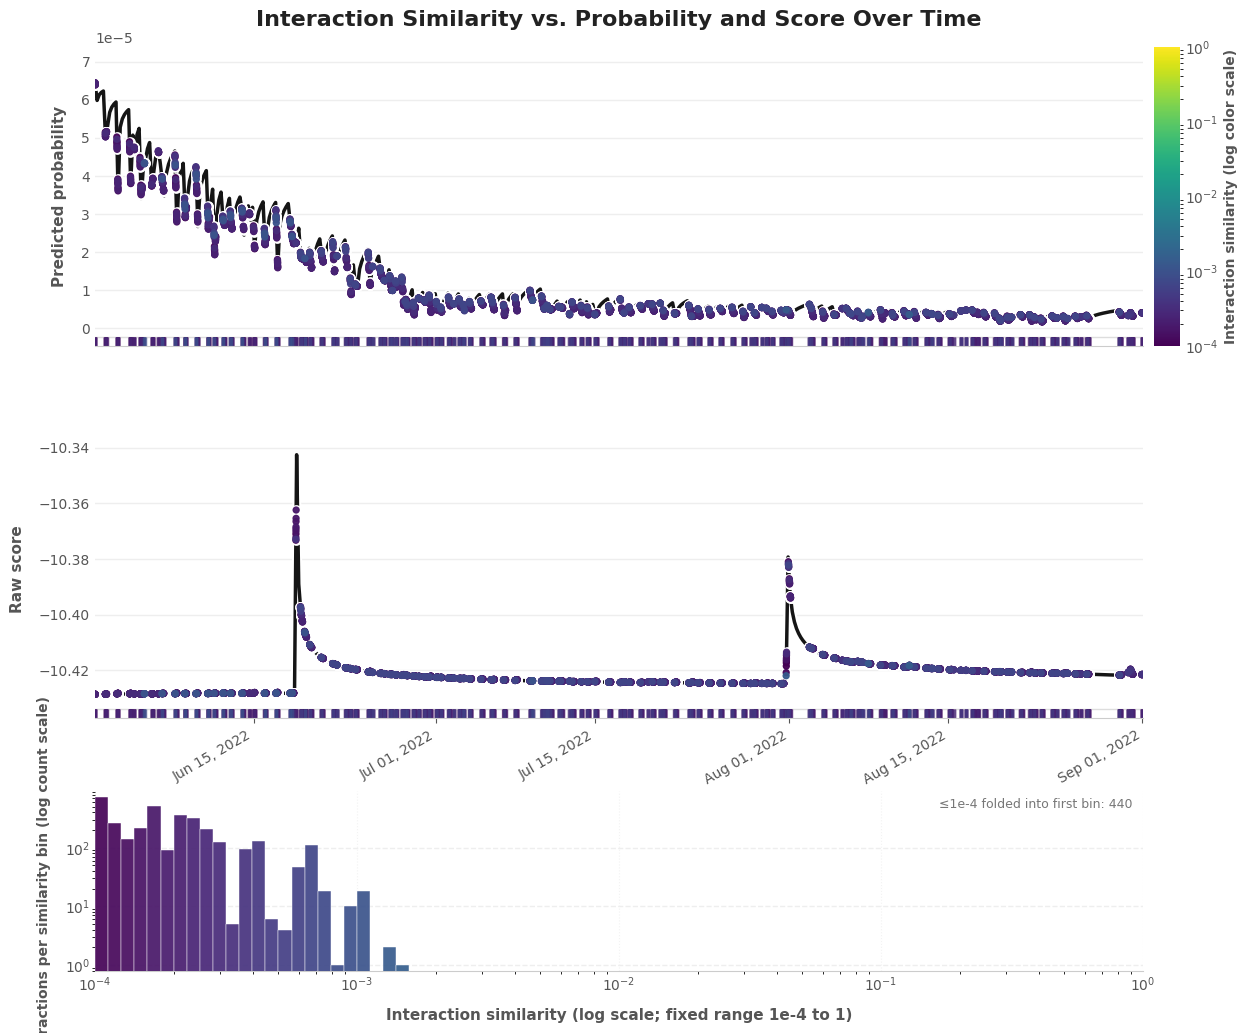

In [14]:
import copy

u = 451
i = 1

lamb = max(weights['model_state_dict']['user_lamb.weight'][u].numpy()[0], 0.001)

print(f"user_lambda:       {lamb}")
print(f"user_change_slope: {(0.2491 ** -0.5) * lamb}")

items = df_full[df_full['user_id'] == u]['track_id'].to_numpy()
ts = df_full[df_full['user_id'] == u]['ts'].to_numpy()

similarities = [sim_matrix[i, x] for x in items]

df = copy.deepcopy(dataframe_dict['extended_doublemlploss'])

curve_prob = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 3]
curve_score = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 2]

plot_dual_interaction_impact(np.asarray(times), np.asarray(curve_prob), np.asarray(curve_score), np.asarray(ts), np.asarray(similarities), min_similarity=None, cmap='viridis')

user_lambda:       0.001
user_change_slope: 0.002003609749252153


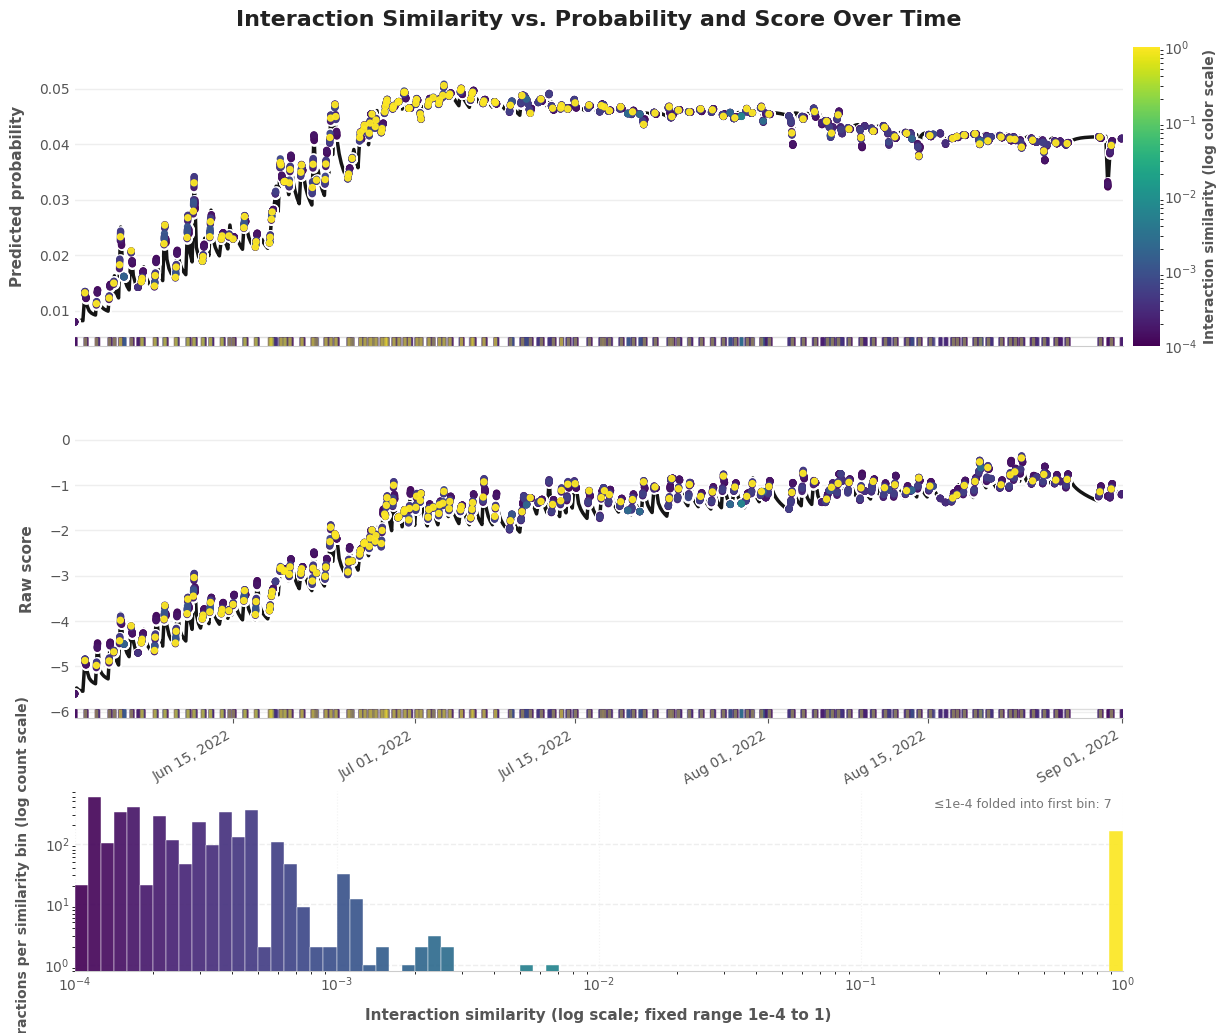

In [15]:
import copy

u = 451
i = 1603

lamb = max(weights['model_state_dict']['user_lamb.weight'][u].numpy()[0], 0.001)

print(f"user_lambda:       {lamb}")
print(f"user_change_slope: {(0.2491 ** -0.5) * lamb}")

items = df_full[df_full['user_id'] == u]['track_id'].to_numpy()
ts = df_full[df_full['user_id'] == u]['ts'].to_numpy()

similarities = [sim_matrix[i, x] for x in items]

df = copy.deepcopy(dataframe_dict['extended_doublemlploss'])

curve_prob = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 3]
curve_score = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 2]

plot_dual_interaction_impact(np.asarray(times), np.asarray(curve_prob), np.asarray(curve_score), np.asarray(ts), np.asarray(similarities), min_similarity=None, cmap='viridis')

In [17]:
np.stack(dataframe_dict['extended_doublemlploss']['prob'].to_numpy()).sum(axis=0).min()

np.float64(0.9999999159686936)

In [18]:
np.stack(dataframe_dict['extended_doublemlploss']['prob'].to_numpy()).sum(axis=0).max()

np.float64(1.0000001018272897)

## Original

In [ ]:
weights = torch.load(r'Z:\Skola\ING\Recommenders\repo\Ex2VecExtended\train_notebooks\weights\original\weights.pt', map_location='cpu', weights_only=False)

smooth = weights['model_state_dict']['smooth'].cpu().numpy()
force = weights['model_state_dict']['force'].cpu().numpy()

user_lambda:       0.001
user_change_slope: 0.002003609749252153


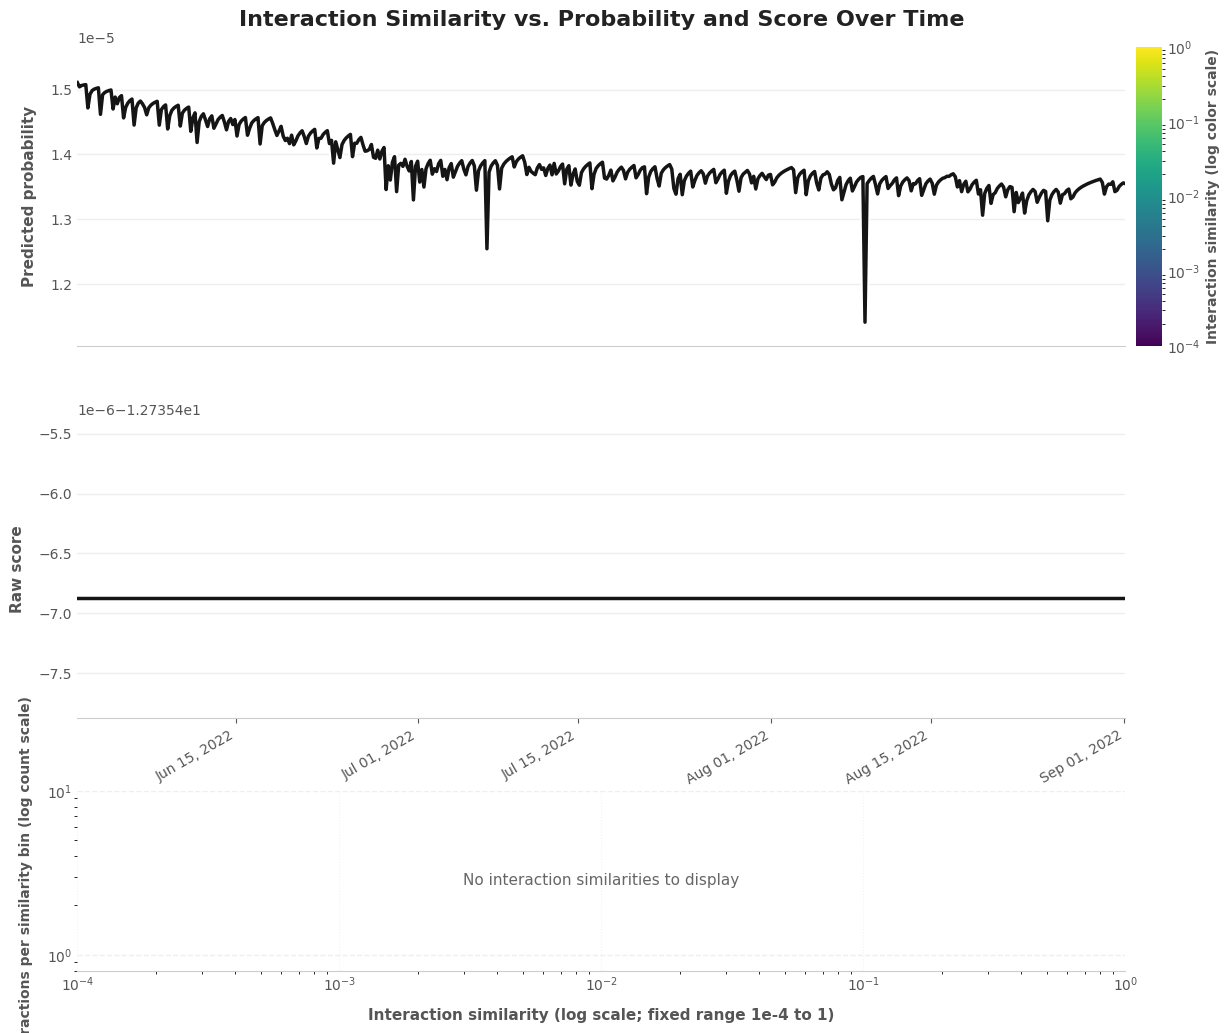

In [30]:
import copy

u = 451
i = 1

lamb = max(weights['model_state_dict']['user_lamb.weight'][u].numpy()[0], 0.001)

print(f"user_lambda:       {lamb}")
print(f"user_change_slope: {(0.2491 ** -0.5) * lamb}")

items = df_full[df_full['user_id'] == u]['track_id'].to_numpy()
ts = df_full[df_full['user_id'] == u]['ts'].to_numpy()

similarities = [sim_matrix[i, x] for x in items]

df = copy.deepcopy(dataframe_dict['original'])

curve_prob = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 3]
curve_score = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 2]

plot_dual_interaction_impact(np.asarray(times), np.asarray(curve_prob), np.asarray(curve_score), np.asarray(ts), np.asarray(similarities), min_similarity=1, cmap='viridis')

user_lambda:       0.001
user_change_slope: 0.002003609749252153
Note: 3279 interaction(s) below min_similarity=1 were excluded. Set min_similarity=None or 0.0 to show the full low-similarity range.


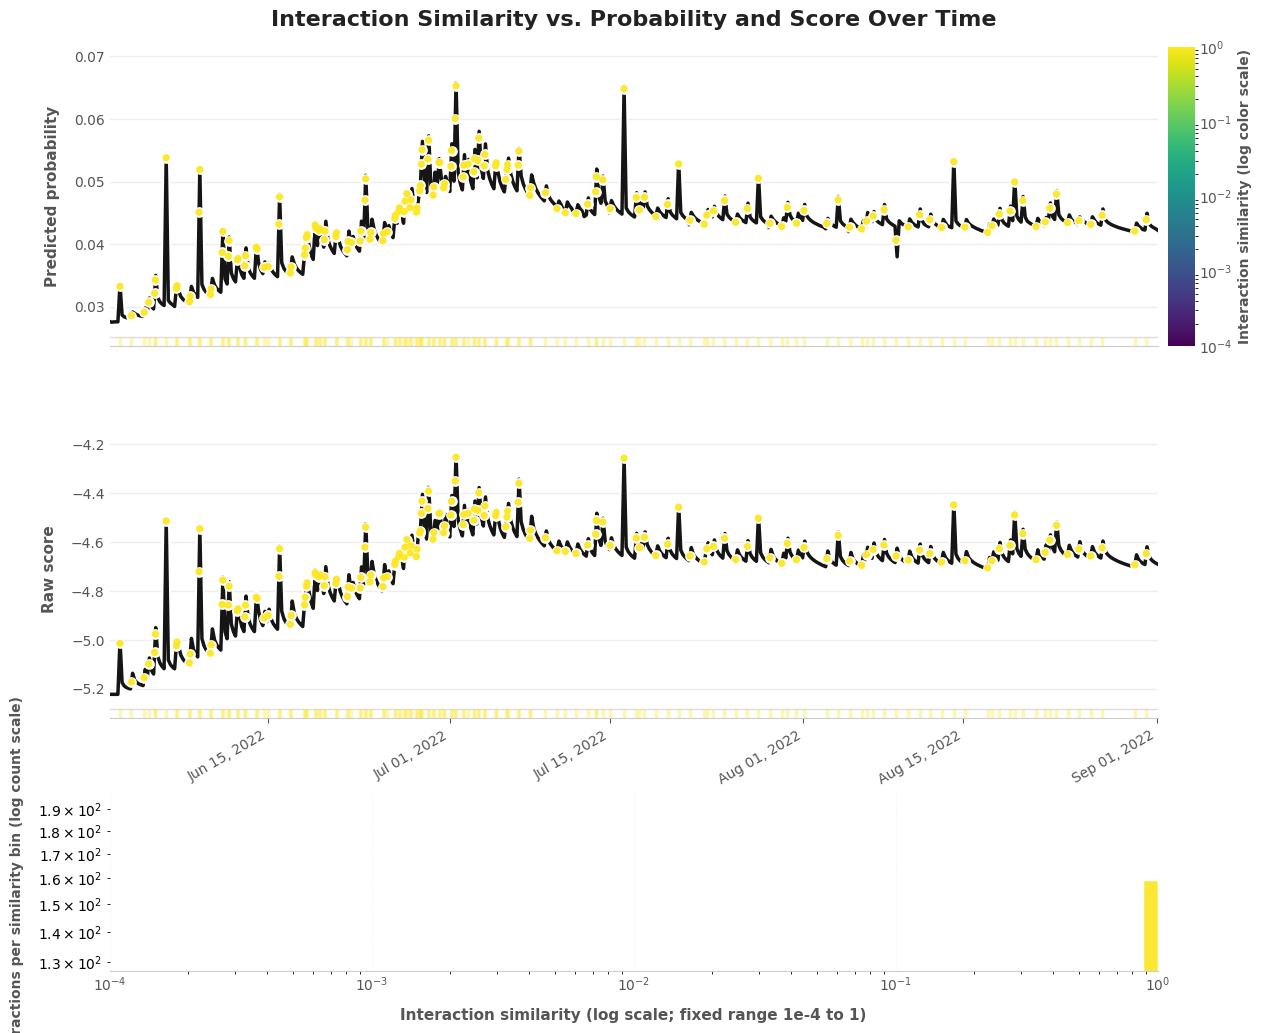

In [31]:
import copy

u = 451
i = 1603

lamb = max(weights['model_state_dict']['user_lamb.weight'][u].numpy()[0], 0.001)

print(f"user_lambda:       {lamb}")
print(f"user_change_slope: {(0.2491 ** -0.5) * lamb}")

items = df_full[df_full['user_id'] == u]['track_id'].to_numpy()
ts = df_full[df_full['user_id'] == u]['ts'].to_numpy()

similarities = [sim_matrix[i, x] for x in items]

df = copy.deepcopy(dataframe_dict['original'])

curve_prob = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 3]
curve_score = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 2]

plot_dual_interaction_impact(np.asarray(times), np.asarray(curve_prob), np.asarray(curve_score), np.asarray(ts), np.asarray(similarities), min_similarity=1, cmap='viridis')

## Similarity Aware

In [24]:
dataframe_dict.keys()

dict_keys(['extended_double', 'extended_doublemlploss', 'extendedBase', 'original'])

In [32]:
weights = torch.load(r'Z:\Skola\ING\Recommenders\repo\Ex2VecExtended\train_notebooks\weights\extendedBase\weights.pt', map_location='cpu', weights_only=False)

smooth = weights['model_state_dict']['smooth'].cpu().numpy()
force = weights['model_state_dict']['force'].cpu().numpy()

In [34]:
from src.models.optimized.extendedBase import Ex2VecExtendedBaseFast

config = weights['config']


model = Ex2VecExtendedBaseFast(config)
model.load_state_dict(weights["model_state_dict"], strict=False)
# model.initialize_histories(torch.tensor(item_history).to(device), torch.tensor(time_history).to(device))
model.to(device)

Ex2VecExtendedBaseFast(
  (user_lamb): Embedding(13210, 1)
  (user_bias): Embedding(13210, 1)
  (item_bias): Embedding(3028, 1)
  (embedding_user): Embedding(13210, 64)
  (embedding_item): Embedding(3028, 64)
  (logistic): Sigmoid()
)

In [36]:
item_emb = model.embedding_item.weight
item_dist_matrix = torch.cdist(item_emb, item_emb).detach().cpu().numpy()
sim_matrix = get_weighted_dist(item_dist_matrix, smooth, force)

user_lambda:       0.001
user_change_slope: 0.002003609749252153


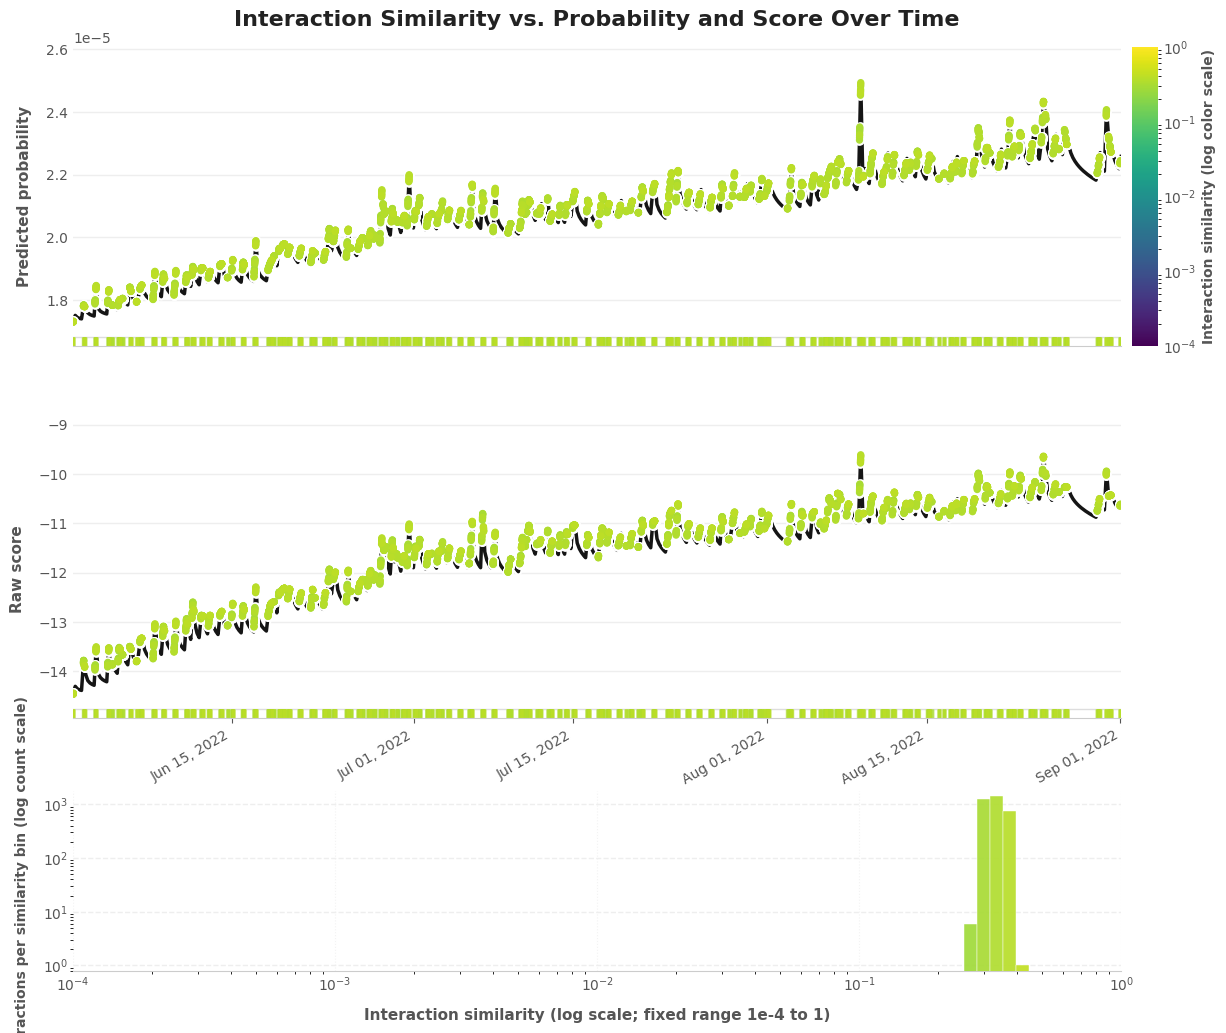

In [37]:
import copy

u = 451
i = 1

lamb = max(weights['model_state_dict']['user_lamb.weight'][u].numpy()[0], 0.001)

print(f"user_lambda:       {lamb}")
print(f"user_change_slope: {(0.2491 ** -0.5) * lamb}")

items = df_full[df_full['user_id'] == u]['track_id'].to_numpy()
ts = df_full[df_full['user_id'] == u]['ts'].to_numpy()

similarities = [sim_matrix[i, x] for x in items]

df = copy.deepcopy(dataframe_dict['extendedBase'])

curve_prob = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 3]
curve_score = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 2]

plot_dual_interaction_impact(np.asarray(times), np.asarray(curve_prob), np.asarray(curve_score), np.asarray(ts), np.asarray(similarities), min_similarity=None, cmap='viridis')

user_lambda:       0.001
user_change_slope: 0.002003609749252153


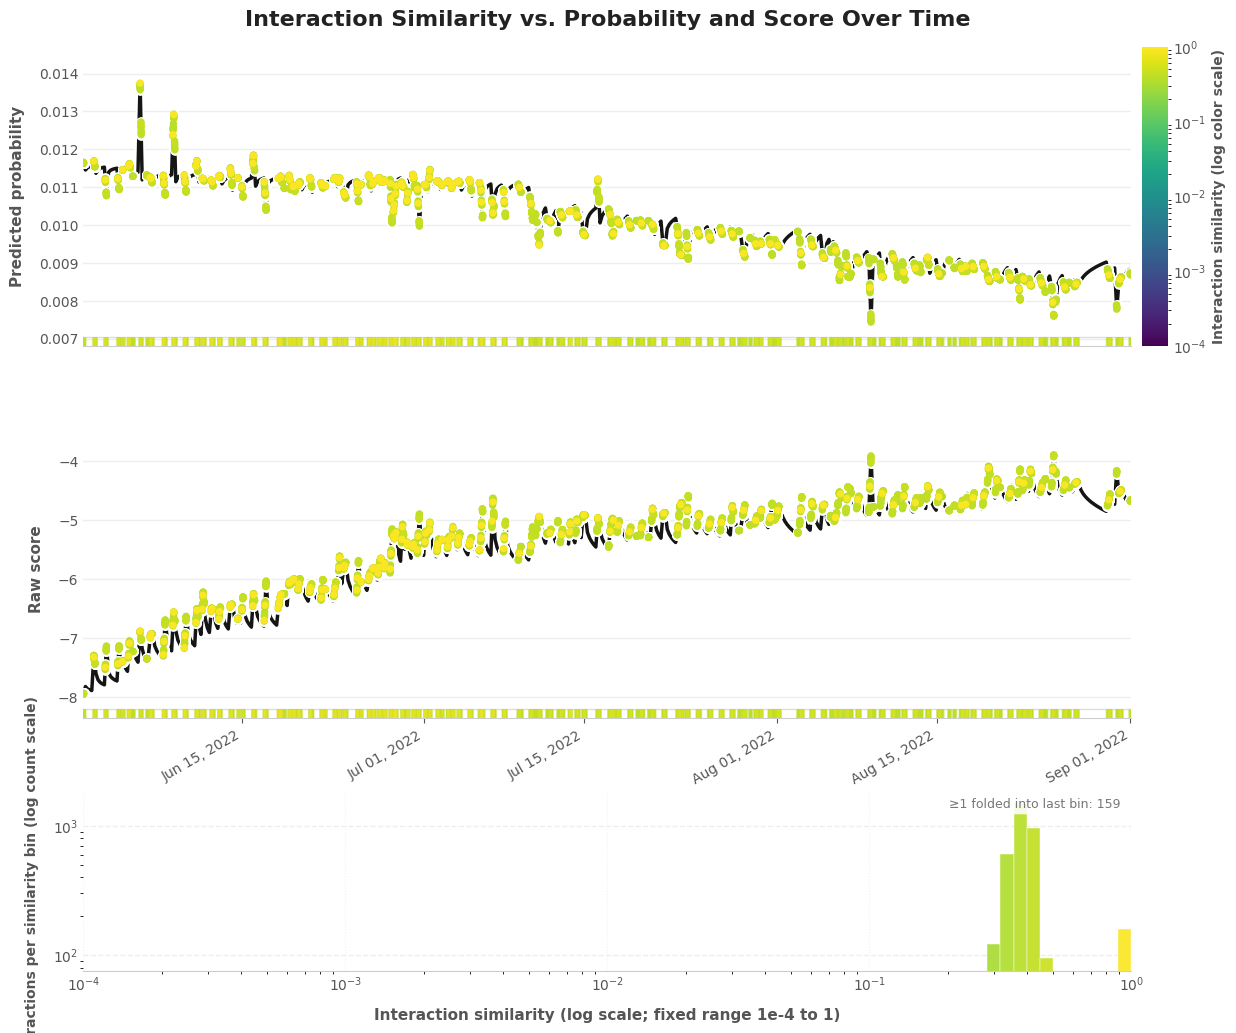

In [38]:
import copy

u = 451
i = 1603

lamb = max(weights['model_state_dict']['user_lamb.weight'][u].numpy()[0], 0.001)

print(f"user_lambda:       {lamb}")
print(f"user_change_slope: {(0.2491 ** -0.5) * lamb}")

items = df_full[df_full['user_id'] == u]['track_id'].to_numpy()
ts = df_full[df_full['user_id'] == u]['ts'].to_numpy()

similarities = [sim_matrix[i, x] for x in items]

df = copy.deepcopy(dataframe_dict['extendedBase'])

curve_prob = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 3]
curve_score = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 2]

plot_dual_interaction_impact(np.asarray(times), np.asarray(curve_prob), np.asarray(curve_score), np.asarray(ts), np.asarray(similarities), min_similarity=None, cmap='viridis')

## Similarity Aware on Pretrained

In [40]:
weights = torch.load(r'Z:\Skola\ING\Recommenders\repo\Ex2VecExtended\train_notebooks\weights\extended_double\weights.pt', map_location='cpu', weights_only=False)

smooth = weights['model_state_dict']['smooth'].cpu().numpy()
force = weights['model_state_dict']['force'].cpu().numpy()

In [42]:

from src.models.optimized.extendedWithEmb import Ex2VecExtendedWithEmbFast

device = 'cuda'
config = {'n_users': user_count, 'n_items': item_count, 'latent_d': 64,
          'pretrained_embeddings_path': r'Z:\Skola\ING\Recommenders\repo\Ex2VecExtended\split_data\track_embeddings.parquet',
          'item_mapping': r'Z:\Skola\ING\Recommenders\repo\Ex2VecExtended\split_data\item_mapping.json'}




model = Ex2VecExtendedWithEmbFast(config)
model.load_state_dict(weights["model_state_dict"], strict=False)
# model.initialize_histories(torch.tensor(item_history).to(device), torch.tensor(time_history).to(device))
model.to(device)

Ex2VecExtendedWithEmbFast(
  (user_lamb): Embedding(13210, 1)
  (user_bias): Embedding(13210, 1)
  (item_bias): Embedding(3028, 1)
  (embedding_user): Embedding(13210, 64)
  (embedding_item): Embedding(3028, 64)
  (logistic): Sigmoid()
  (embedding_item_extension): Embedding(3028, 128)
)

In [43]:
item_emb = model.embedding_item.weight
item_dist_matrix = torch.cdist(item_emb, item_emb).detach().cpu().numpy()
sim_matrix = get_weighted_dist(item_dist_matrix, smooth, force)

user_lambda:       1.0825024843215942
user_change_slope: 2.168912410736084


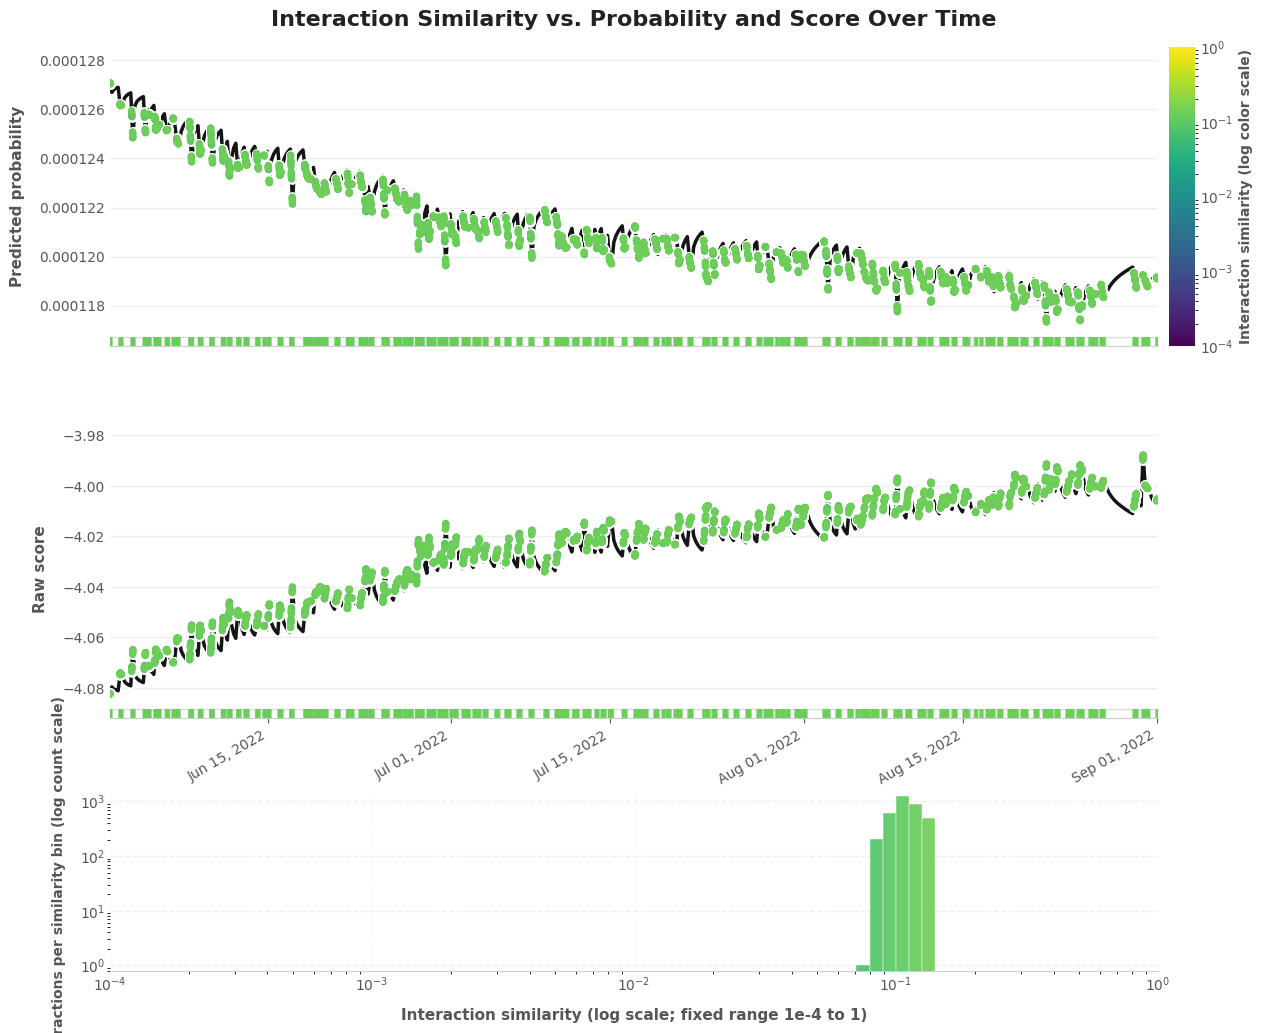

In [44]:
import copy

u = 451
i = 1

lamb = max(weights['model_state_dict']['user_lamb.weight'][u].numpy()[0], 0.001)

print(f"user_lambda:       {lamb}")
print(f"user_change_slope: {(0.2491 ** -0.5) * lamb}")

items = df_full[df_full['user_id'] == u]['track_id'].to_numpy()
ts = df_full[df_full['user_id'] == u]['ts'].to_numpy()

similarities = [sim_matrix[i, x] for x in items]

df = copy.deepcopy(dataframe_dict['extended_double'])

curve_prob = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 3]
curve_score = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 2]

plot_dual_interaction_impact(np.asarray(times), np.asarray(curve_prob), np.asarray(curve_score), np.asarray(ts), np.asarray(similarities), min_similarity=None, cmap='viridis')

user_lambda:       1.0825024843215942
user_change_slope: 2.168912410736084


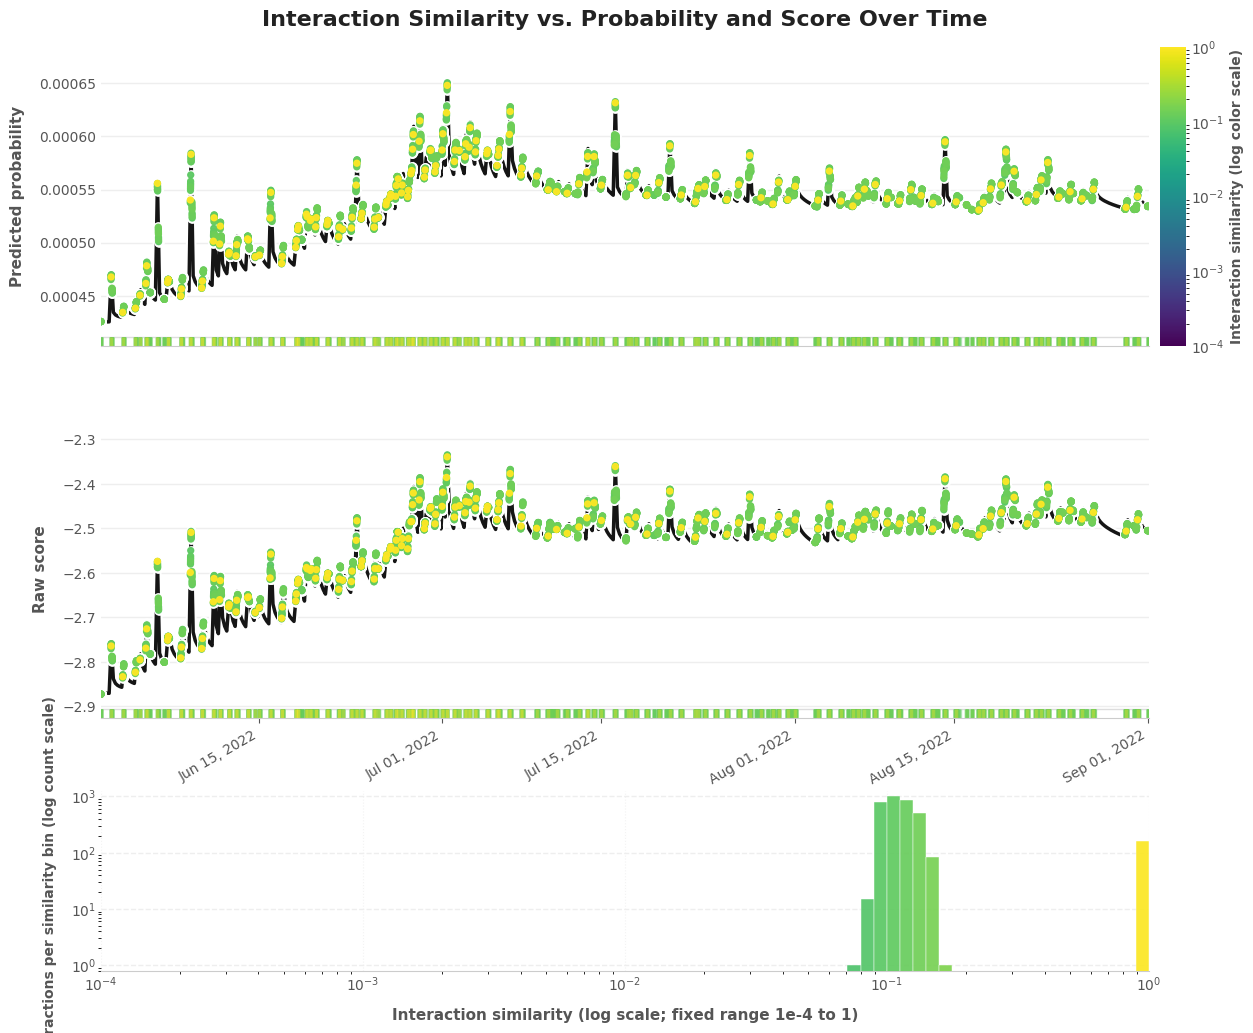

In [45]:
import copy

u = 451
i = 1603

lamb = max(weights['model_state_dict']['user_lamb.weight'][u].numpy()[0], 0.001)

print(f"user_lambda:       {lamb}")
print(f"user_change_slope: {(0.2491 ** -0.5) * lamb}")

items = df_full[df_full['user_id'] == u]['track_id'].to_numpy()
ts = df_full[df_full['user_id'] == u]['ts'].to_numpy()

similarities = [sim_matrix[i, x] for x in items]

df = copy.deepcopy(dataframe_dict['extended_double'])

curve_prob = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 3]
curve_score = df[(df['user'] == u) & (df['item'] == i)].iloc[0, 2]

plot_dual_interaction_impact(np.asarray(times), np.asarray(curve_prob), np.asarray(curve_score), np.asarray(ts), np.asarray(similarities), min_similarity=None, cmap='viridis')